# Nivell 1

## 1. Connecta Python amb MySQL Workbench i carrega les dades de la teva base de dades del Sprint 4 per utilitzar-les en tots els exercicis.

In [2]:
%pip install mysql-connector-python python-dotenv

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import mysql.connector
from mysql.connector import Error
import os                    
from dotenv import load_dotenv   
import pandas as pd     
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import StrMethodFormatter


In [4]:
load_dotenv()

True

In [5]:
try:
    conexion = mysql.connector.connect(
        host=os.getenv('MYSQL_HOST', '127.0.0.1'),
        database=os.getenv('MYSQL_DATABASE'),
        user=os.getenv('MYSQL_USER'),
        password=os.getenv('MYSQL_PASSWORD'),
        
    )

    
    cursor = conexion.cursor()
    cursor.execute('SHOW TABLES')
    tablas = [tabla[0] for tabla in cursor.fetchall()] 
    cursor.close()
    
    print(f"Contiene {len(tablas)} tablas: {tablas}")

    for tabla in tablas:
        globals()[tabla] = pd.read_sql(f'SELECT * FROM {tabla}', conexion)

    print('Se han cargado todas las tablas')

except Error as e:
    print('Error:', e)

Contiene 7 tablas: ['companies', 'credit_cards', 'estado_credit_cards', 'products', 'transaction_product', 'transactions', 'users']


C:\Users\torre\AppData\Local\Temp\ipykernel_23408\4147813143.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  globals()[tabla] = pd.read_sql(f'SELECT * FROM {tabla}', conexion)


Se han cargado todas las tablas


# 2. Per a cada ítem, crea una visualització adequada segons les variables especificades. Interpreta els resultats segons les teves dades.

Recorda: quan seleccionis les columnes, pensa sempre en el mètode que faràs servir i inclou les que calguin per a la funció de visualització que vulguis utilitzar.

- Una variable numèrica.
- Dues variables numèriques.
- Una variable categòrica.
- Una variable categòrica i una numèrica.
- Dues variables categòriques.
- Tres variables combinades.
- Crea un Pairplot.

## Una variable Numèrica

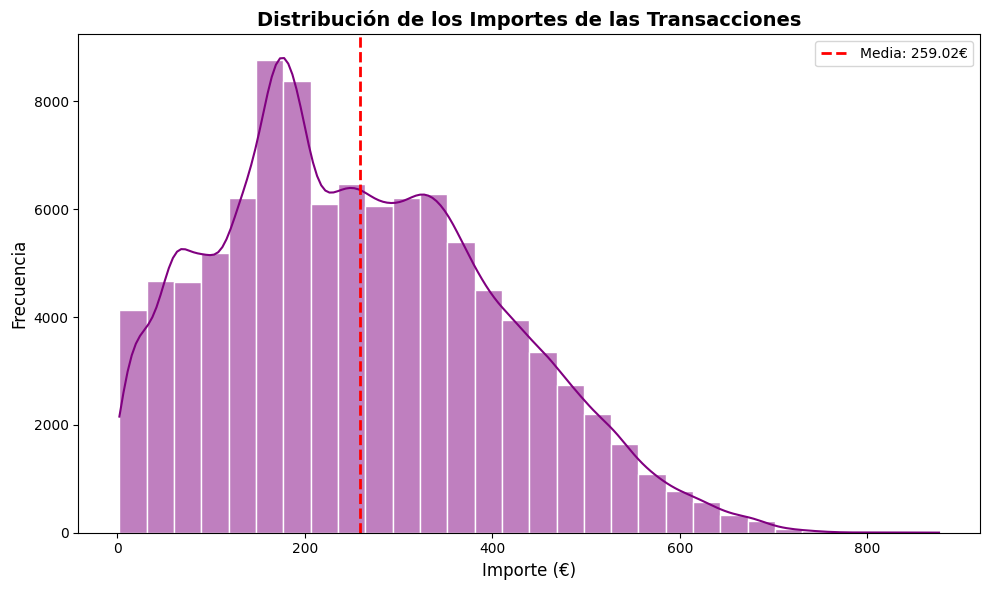

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(data=transactions, x='amount', bins=30, kde=True, 
             color='purple', edgecolor='white')
plt.title('Distribución de los Importes de las Transacciones', fontsize=14, fontweight='bold')
plt.xlabel('Importe (€)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)


mean_amount = transactions['amount'].mean()
plt.axvline(mean_amount, color='red', linestyle='--', linewidth=2, 
            label=f'Media: {mean_amount:.2f}€')
plt.legend()
plt.tight_layout()
plt.show()


### Interpretación
En el histograma se observa la distribución de los importes de los tiquets de compra, los cuales muestran una concentración en los tiquets de importe entre 150$ y 200$ y una reducción proresiva hasta el tiquet de importe máximo 

## Dues variables numèriques

In [21]:
ventas = transaction_product.groupby('product_id').agg(
    num_ventas=('transaction_id', 'count')
).reset_index()
ventas = ventas.merge(
    products[['id', 'price']],
    left_on='product_id',
    right_on='id',
    how='left'
)

ventas['ingresos'] = ventas['num_ventas'] * ventas['price']

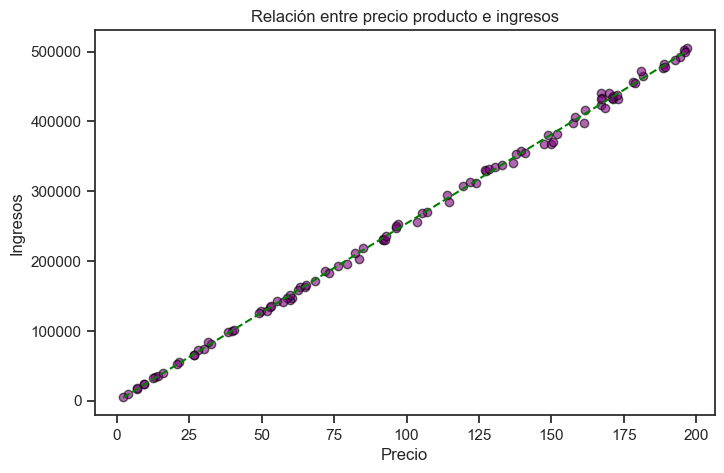

In [22]:
plt.figure(figsize=(8,5))

plt.scatter(
    ventas['price'],
    ventas['ingresos'],
    color= 'purple',
    alpha=0.6,        
    edgecolor='black' 
)
m, b = np.polyfit(
    ventas['price'],
    ventas['ingresos'],
    1
)
x = np.linspace(
    ventas['price'].min(),
    ventas['price'].max(),
    100 
    
)
plt.plot(
    x,
    m*x + b,
    linestyle="--",
    color = 'green'
)
plt.xlabel('Precio')
plt.ylabel('Ingresos')
plt.title('Relación entre precio producto e ingresos')

plt.show()

In [50]:
transaction_product.head()

,transaction_id,product_id,declined
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,16,0
1,00043A49-2949-494B-A5DD-A5BAE3BB19DD,26,0
2,00043A49-2949-494B-A5DD-A5BAE3BB19DD,87,0
3,00043A49-2949-494B-A5DD-A5BAE3BB19DD,97,0
4,000447FE-B650-4DCF-85DE-C7ED0EE1CAAD,66,0


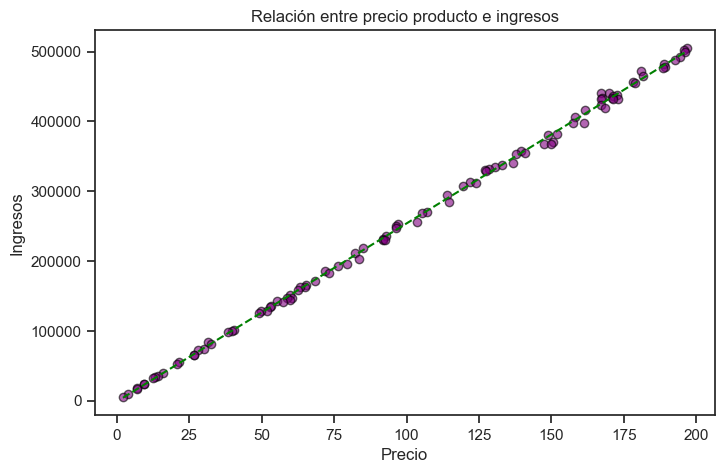

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

dataset = transaction_product.merge(
    products,
    left_on='product_id',
    right_on='id',
    how='inner'
).merge(
    transactions,
    left_on='transaction_id',
    right_on='id',
    how='inner'
)[['product_id','transaction_id', 'price']]

ventas = (
    dataset.groupby('product_id')
    .agg(
        num_ventas=('transaction_id', 'count'),
        price=('price', 'first')
    )
    .reset_index()
)

ventas['ingresos'] = ventas['num_ventas'] * ventas['price']

ventas = ventas.sort_values(
    by='ingresos',
    ascending=False
)
plt.figure(figsize=(8,5))

plt.scatter(
    ventas['price'],
    ventas['ingresos'],
    color= 'purple',
    alpha=0.6,        
    edgecolor='black' 
)
m, b = np.polyfit(
    ventas['price'],
    ventas['ingresos'],
    1
)
x = np.linspace(
    ventas['price'].min(),
    ventas['price'].max(),
    100 
    
)
plt.plot(
    x,
    m*x + b,
    linestyle="--",
    color = 'green'
)
plt.xlabel('Precio')
plt.ylabel('Ingresos')
plt.title('Relación entre precio producto e ingresos')
plt.show()


### Interpretación
Se observa la relación entre los precios de los productos y los ingresos que generan, a medida que el precio del producto aumenta lo hacen también los ingresos, por tanto la relación es positiva.

## Una variable categòrica

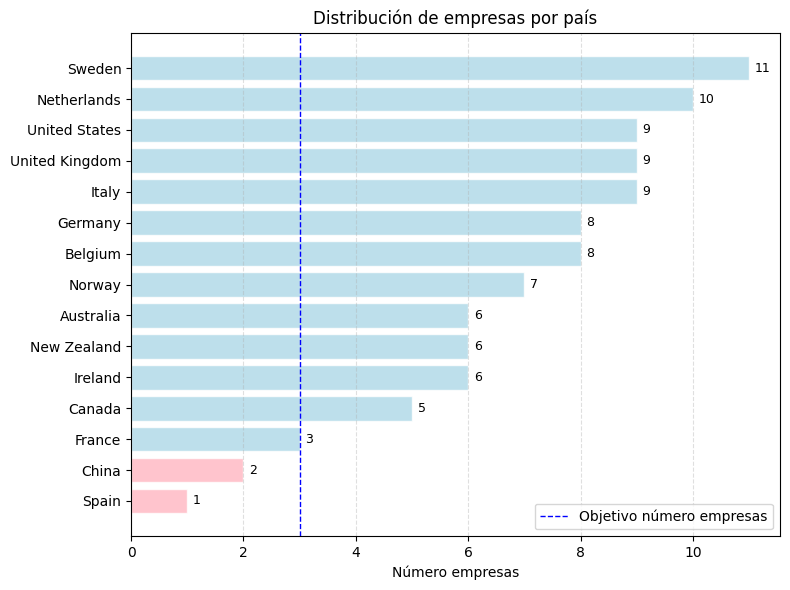

In [9]:

empresas_pais = companies['country'].value_counts()

fig, ax = plt.subplots(figsize=(8, 6))


objetivo = 3
colors = ['lightpink' if valor < objetivo else 'lightblue' for valor in empresas_pais.values]


ax.barh(empresas_pais.index, empresas_pais.values, color= colors, alpha = 0.8,edgecolor= 'white')

for i, v in enumerate(empresas_pais.values):
    ax.text(v + 0.1, i, str(v), va='center', fontsize=9)

ax.set_xlabel('Número empresas')
ax.set_title('Distribución de empresas por país')
ax.invert_yaxis() 
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.axvline(x=3, color='blue', linestyle='--', linewidth=1, label='Objetivo número empresas')
plt.legend()
plt.tight_layout()
plt.show()



### Interpretación
Se analiza el número de empresas por país, y si se encuentran dentro del objetivo de 3 empresas. Se observa como la mayoría de paises cumple con el objetivo a excepción de dos paises: China y España.

## Una variable categòrica i una numèrica

In [10]:
transaction_companies = transactions.merge(
    companies,
    left_on = 'company_id',
    right_on = 'company_id',
    how = 'left'
)

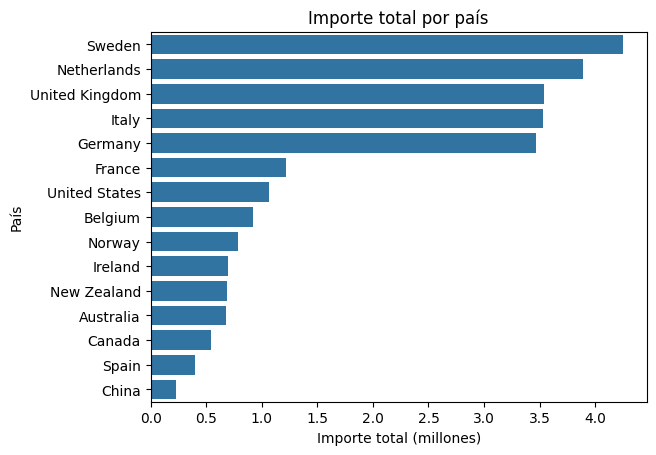

In [11]:
amount_pais = (
    transaction_companies
    .groupby('country')['amount']
    .sum()
    .reset_index()
    .sort_values('amount', ascending=False)
)

amount_pais['amount_millones'] = amount_pais['amount'] / 1_000_000

sns.barplot(
    data=amount_pais,
    x='amount_millones',
    y='country'
)

plt.xlabel('Importe total (millones)')
plt.ylabel('País')
plt.title('Importe total por país')

plt.show()

### Interpretación
Se observa como los ingresos no se distribuyen de forma uniforme, 5 paises concentran una parte importante del importe de las transacciones, mientras que la actividad en otros es cosidrebalemnte más baja.

## Dos variables categóricas

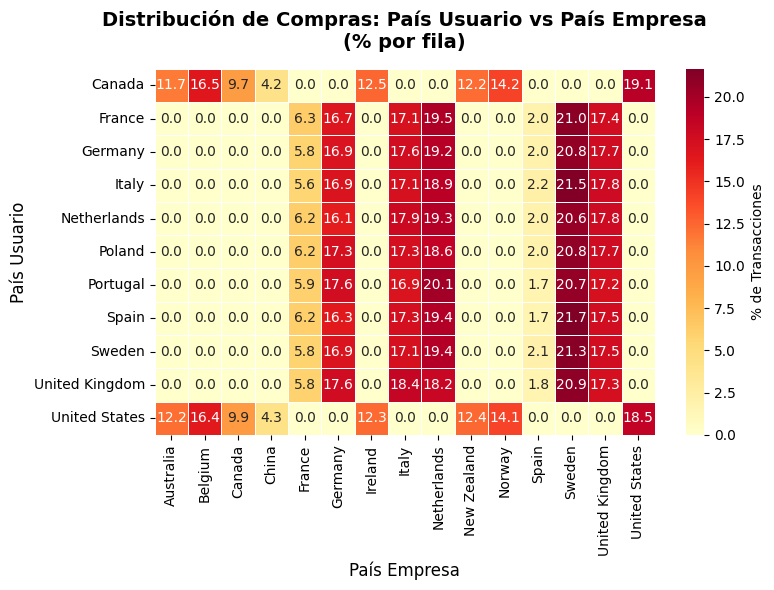

In [12]:

df_heatmap = transactions.merge(
    users[['id', 'country']],
    left_on='user_id',
    right_on='id',
    how='left'
).rename(columns={'country': 'country_user'})

    
df_heatmap =  df_heatmap.merge(
    companies[['company_id', 'country']],
    on='company_id',
    how='left'
).rename(columns={'country': 'country_company'})


tabla_conteo = pd.crosstab(df_heatmap['country_user'], df_heatmap['country_company'])


tabla_porcentajes = pd.crosstab(
    df_heatmap['country_user'], 
    df_heatmap['country_company'], 
    normalize='index'
) * 100


fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    tabla_porcentajes, 
    annot=True, 
    fmt='.1f', 
    cmap='YlOrRd', 
    ax=ax,
    linewidths=0.5,
    cbar_kws={'label': '% de Transacciones'}
)

ax.set_xlabel('País Empresa', fontsize=12)
ax.set_ylabel('País Usuario', fontsize=12)
ax.set_title('Distribución de Compras: País Usuario vs País Empresa\n(% por fila)', 
             fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()



### Interpretación

Se muestra el porcentaje de compras que realizan los usuarios, relacionando el país del usuario (fila) con el país donde realiza la compra (columna), puediendo indentificar si los usuarios realizan compras locales o globales.
El color rojo intenso identifica el porcentaje mayor de compras, así, podemos indentificar que Estados Unidos y Canadá concentran sus compras en sus propios mercados y los usuarios del continente europeo concentran las suyas en sus mercados, principalmente en Noruega.

## Tres variables combinades

In [13]:
total_amount = transactions.merge(
    companies[['company_id', 'company_name', 'country']],
    on='company_id',
    how='left'
)


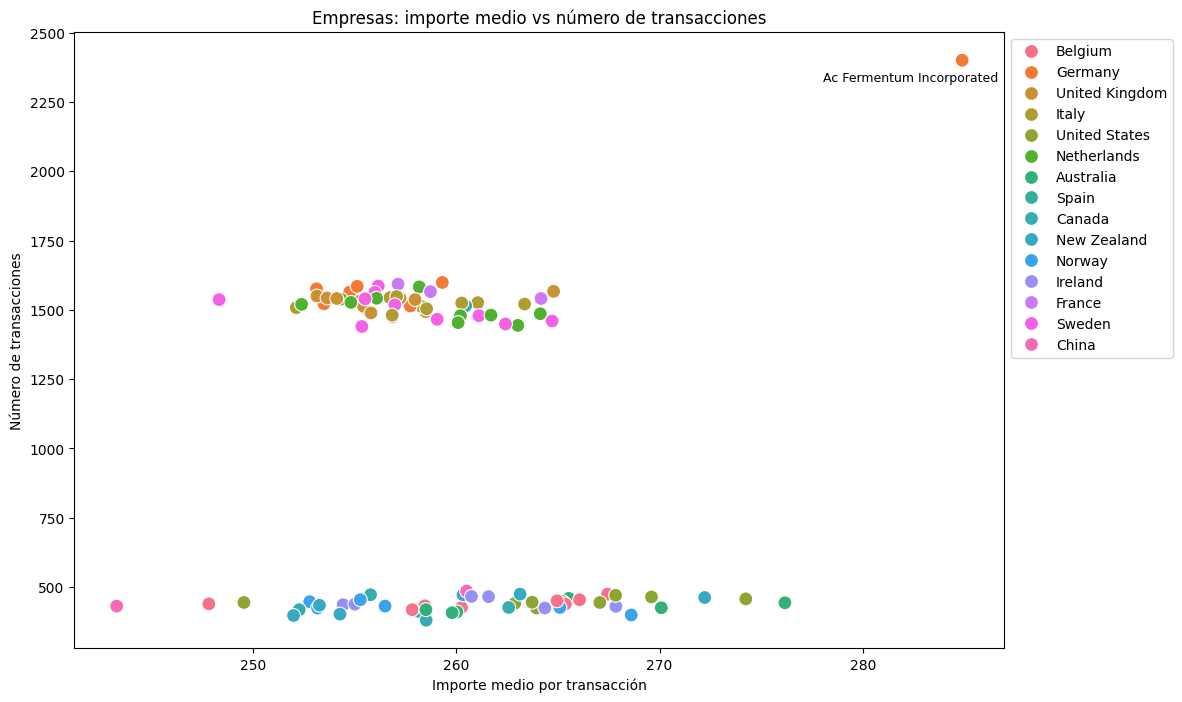

In [14]:
df_empresas = (
    total_amount
    .groupby(['company_name', 'country'])
    .agg(
        amount_medio=('amount', 'mean'),
        num_transacciones=('amount', 'count')
    )
    .reset_index()
)


plt.figure(figsize=(12,8))

ax = sns.scatterplot(
    data=df_empresas,
    x='amount_medio',
    y='num_transacciones',
    hue='country',
    s=100
)

outlier_max = df_empresas.loc[df_empresas['num_transacciones'].idxmax()]


ax.annotate(outlier_max['company_name'],   
        xy=(outlier_max['amount_medio'], outlier_max['num_transacciones']),
        xytext=(-100, -15),             
        textcoords='offset points',
        fontsize=9,
        color='black')

plt.xlabel('Importe medio por transacción')
plt.ylabel('Número de transacciones')
plt.title('Empresas: importe medio vs número de transacciones')
ax.legend(bbox_to_anchor=(1, 1), loc='upper left') 

plt.show()

### Interpretación

Se observa dos grupos claramente diferenciados, el primero con el número de transaccines por debajo de 500 y el otro alrededor de las 1500. 
Además se observa una empresa que destaca por encima del resto con un volumen de transacciones superior a las 2300 y con un importe medio de más de 285$, se incluye el nombre de la empresa para darle más visibilidad.

## Crea un Pairplot

In [15]:
from funciones import calcular_edad
users['age'] = users['birth_date'].apply(calcular_edad)
transaction_users = transactions.merge(
    users[['id', 'age', 'country']],
    left_on='user_id',
    right_on='id',
    how='left'
)

transaction_users = transaction_users.groupby(['user_id','age'])['amount'].sum().reset_index()

transaction_users['grupo_edad'] = pd.cut(
    transaction_users['age'],
    bins=[18, 30, 45, 60, 80],
    labels=['18-30', '31-45', '46-60', '61-80']
)

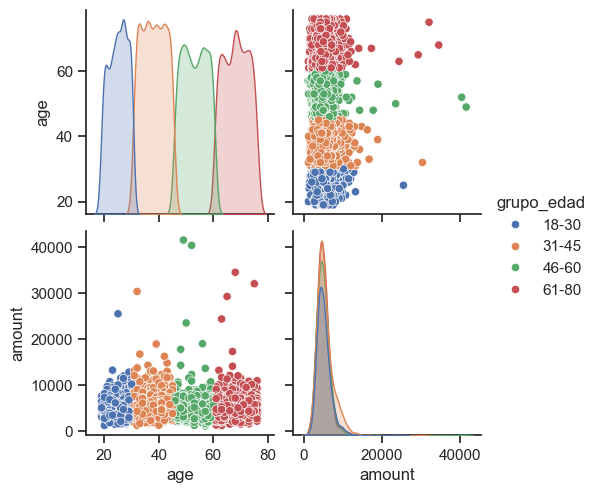

In [16]:

sns.set_theme(style='ticks')
sns.pairplot(
    transaction_users[['age', 'amount', 'grupo_edad']],
    hue='grupo_edad',
    diag_kind='kde'
)
plt.show()

### Interpretación

El pairplot muestra la distribución de las edades de los usuarios y de los importes de sus transacciones. La variable Amount muestra una distribución asimétrica, concentrando en los importes bajos. La variable edad muestra más volumen de usuarios en el rango de 31-45. 
La relación entre ambas variables no muestra una correlación significativa dado que los importes de las transacciones se distribuyen de forma similar entre los grupos de edad, No obstante, se identifican algunos valores atípicos, especialmente en los grupos de 46-60 años y 61-80 años, donde aparecen transacciones de importe excepcionalmente alto.

# Nivell 2

## 1. Representa la correlació d'algunes variables i interpreta els resultats segons les teves dades.

In [17]:
df_corr = transactions.merge(
    users[['id','age']],
    left_on='user_id',
    right_on='id',
    how='left'
)

df_corr = df_corr[['age','amount']]

corr = df_corr.corr()
print(corr)

             age    amount
age     1.000000 -0.001635
amount -0.001635  1.000000


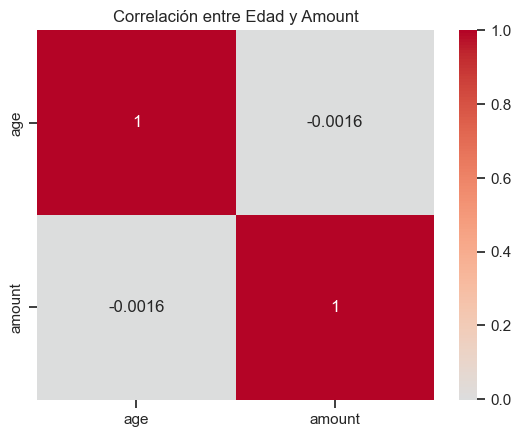

In [18]:
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlación entre Edad y Amount')
plt.show()

### Interpretación

Se analiza la correlación entre las variables edad y amount, el resultado no muestra una correlación significativa dado que los valores son cercanos a 0, por lo tanto las variables se consideran independientes. 

## 2. Implementa un Jointplot per explorar la relació entre dues variables i interpreta els resultats segons les teves dades.

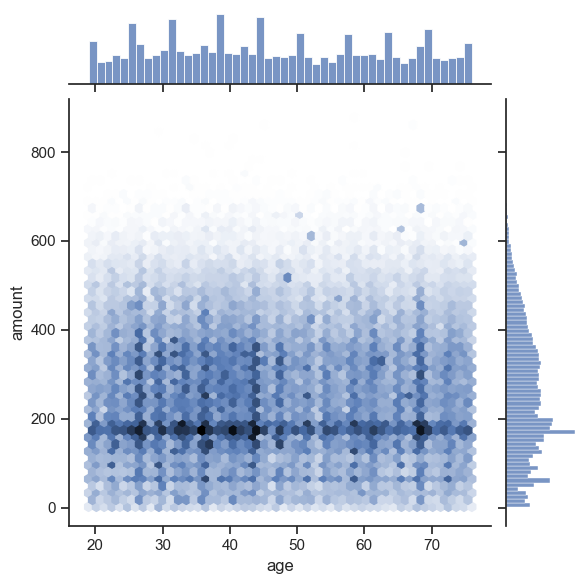

In [19]:
sns.jointplot(
    x='age',
    y='amount',
    data=df_corr,
    kind='hex' 
)

### Interpretación

Se observa la relación entre la edad de los usuarios y el importe de sus transacciones. La mayor concentración de transacciones se sitúa en importes comprendidos entre 100 y 250, independientemente de la edad del usuario. 
No muestra una relación significativa entre ambas variables, ya que los importes se distribuyen de forma similar entre los grupos de edad. 
La distribución de los importes presenta concentración de transacciones de bajo importe y una menor frecuencia de operaciones de importe elevado.
